In [42]:
import pandas as pd 
df=pd.read_csv("polylinearregression.csv")
df

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [43]:
y=df[['Pressure']]
x=df[["Temperature"]]

In [44]:
# from sklearn.model_selection import train_test_split
# x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=1,test_size=0.2)
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)
y_pred=lr.predict(x)
print("Coeffiecet m: ",lr.coef_)
print("Intercept c: ",lr.intercept_)

from sklearn import metrics
print("MEA : ",metrics.mean_absolute_error(y,y_pred))
print("MSA : ",metrics.mean_squared_error(y,y_pred))
print("R2 : ",metrics.r2_score(y,y_pred))

Coeffiecet m:  [[0.002342]]
Intercept c:  [-0.05086667]
MEA :  0.047653333333333346
MSA :  0.002870267555555557
R2 :  0.690349972603981


C:\Users\LJENG\AppData\Local\Temp\ipykernel_4832\445859238.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


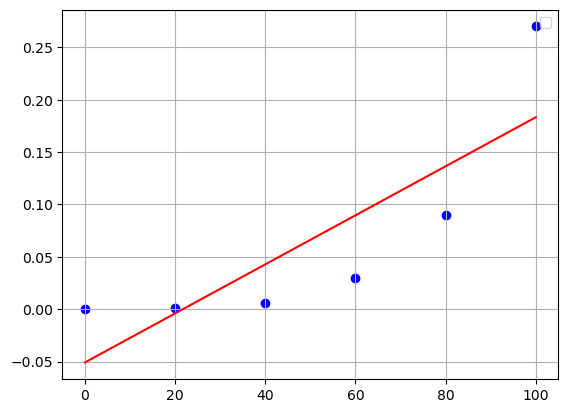

In [45]:
import matplotlib.pyplot as plt
plt.scatter(x,y , color='blue')
plt.plot(x,y_pred,color='r')
plt.legend()
plt.grid(True)
plt.show()

In [50]:
# import seaborn as sns
# sns.regplot(data=df,x="Temperature",y="Pressure")

# New 

In [63]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3) # degree badali ne joi levanu 
x_poly=poly.fit_transform(x)
print(x_poly)
y_poly=poly.fit_transform(y)
print("\n\n",y_poly)

[[1.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [1.00e+00 2.00e+01 4.00e+02 8.00e+03]
 [1.00e+00 4.00e+01 1.60e+03 6.40e+04]
 [1.00e+00 6.00e+01 3.60e+03 2.16e+05]
 [1.00e+00 8.00e+01 6.40e+03 5.12e+05]
 [1.00e+00 1.00e+02 1.00e+04 1.00e+06]]


 [[1.0000e+00 2.0000e-04 4.0000e-08 8.0000e-12]
 [1.0000e+00 1.2000e-03 1.4400e-06 1.7280e-09]
 [1.0000e+00 6.0000e-03 3.6000e-05 2.1600e-07]
 [1.0000e+00 3.0000e-02 9.0000e-04 2.7000e-05]
 [1.0000e+00 9.0000e-02 8.1000e-03 7.2900e-04]
 [1.0000e+00 2.7000e-01 7.2900e-02 1.9683e-02]]


In [64]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)

print("Coeffiecet m: ",lr.coef_)
print("Intercept c: ",lr.intercept_)

from sklearn import metrics
print("MEA : ",metrics.mean_absolute_error(y,y_pred))
print("MSA : ",metrics.mean_squared_error(y,y_pred))
print("R2 : ",metrics.r2_score(y,y_pred)) # imporve

Coeffiecet m:  [[ 0.00000000e+00  1.36546296e-03 -5.98055556e-05  7.30787037e-07]]
Intercept c:  [-0.00198889]
MEA :  0.004899999999994181
MSA :  3.0875185185185205e-05
R2 :  0.9966691251761722


C:\Users\LJENG\AppData\Local\Temp\ipykernel_4832\445859238.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


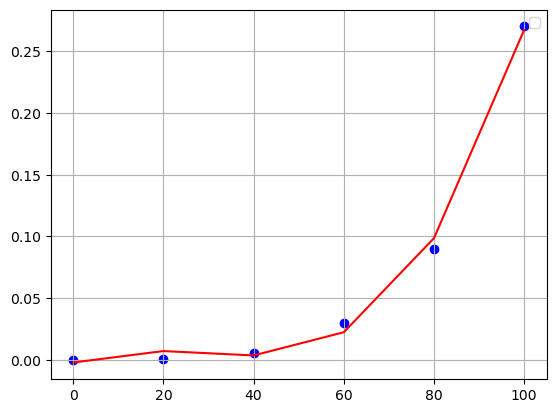

In [65]:
import matplotlib.pyplot as plt
plt.scatter(x,y , color='blue')
plt.plot(x,y_pred,color='r')
plt.legend()
plt.grid(True)
plt.show()

In [66]:
## car_data.csv Underscode

In [68]:
import pandas as pd 
df=pd.read_csv("car_data.csv")
df

,Horsepower,Weight,MPG
0,130,3504,18
1,165,3693,15
2,150,3436,18
3,140,3433,16
4,198,4341,14
5,220,4354,12
6,95,2372,25
7,88,2130,27
8,98,2228,24


In [74]:
y=df["MPG"]
x=df.drop(columns="MPG")
print(x.shape)
y.shape

(9, 2)


(9,)

In [92]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3) # degree badali ne joi levanu 
x_poly=poly.fit_transform(x)
# print(x_poly)

In [93]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_poly,y,test_size=0.2,random_state=1) 
print(x_train.shape)

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
diff=pd.DataFrame({"Actualy":y_test,"Preidct":y_pred})


(7, 10)


In [94]:
print("Coeffecitn m : ",lr.coef_)
print("Intercept c : ",lr.intercept_)

Coeffecitn m :  [-2.23514227e-13 -3.06872702e-08  5.64060078e-07 -3.41991246e-06
 -5.75531084e-05 -1.54861175e-06 -2.48596430e-04  3.28961964e-05
 -1.42948051e-06  2.10056916e-08]
Intercept c :  39.36244465383405


In [95]:
from sklearn import metrics
print("\nMAE: ",metrics.mean_absolute_error(y_test,y_pred))
print("MSE: ",metrics.mean_squared_error(y_test,y_pred))
print("R2 Score: ",metrics.r2_score(y_test,y_pred))


MAE:  1.8819815956242962
MSE:  3.543407864452031
R2 Score:  0.6062880150608854


## Square mate 

In [109]:
import pandas as pd
x=[1,2,3,4,5]
y=[1,4,9,16,25]
x=pd.DataFrame(x)
y=pd.Series(y)
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)# degree badali ne joi levanu 
x_poly=poly.fit_transform(x)

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)

from sklearn import metrics
print("R2 Score: ",metrics.r2_score(y,y_pred))

R2 Score:  1.0


## Qubic 

In [111]:
import pandas as pd
x=[1,2,3,4,5]
y=[1,8,27,64,125]
x=pd.DataFrame(x)
y=pd.Series(y)
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3) # degree badali ne joi levanu 
x_poly=poly.fit_transform(x)

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)

from sklearn import metrics
print("R2 Score: ",metrics.r2_score(y,y_pred))

R2 Score:  1.0


In [101]:
# from sklearn.preprocessing import PolynomialFeatures
# poly=PolynomialFeatures(degree=10) # degree badali ne joi levanu 
# x_poly=poly.fit_transform(x)
# from sklearn.model_selection import train_test_split
# x_train,x_test,y_train,y_test=train_test_split(x_poly,y,test_size=0.2,random_state=1) 
# print(x_train.shape)
# from sklearn.linear_model import LinearRegression
# lr=LinearRegression()
# lr.fit(x_train,y_train)
# y_pred=lr.predict(x_test)
# diff=pd.DataFrame({"Actualy":y_test,"Preidct":y_pred})
# print("Coeffecitn m : ",lr.coef_)
# print("Intercept c : ",lr.intercept_)
# from sklearn import metrics
# print("\nMAE: ",metrics.mean_absolute_error(y_test,y_pred))
# print("MSE: ",metrics.mean_squared_error(y_test,y_pred))
# print("R2 Score: ",metrics.r2_score(y_test,y_pred))